# SOP 2 EVALUATION NOTEBOOK
## Real-Time Cyber-Aggression Detection and Mitigation
### Using Naive Bayes and VADER in a Chromium-based Browser Extension
**Pamantasan ng Cabuyao — BSCS Thesis 2026**

**Evaluation Tool:** Python scikit-learn + Jupyter Notebook

This notebook evaluates the hybrid model against single-algorithm approaches to answer:
- **SOP 2.1** — Precision
- **SOP 2.2** — Recall
- **SOP 2.3** — F1-Score

In [1]:
# CELL 1 — Import Libraries
import json, math, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime

analyzer = SentimentIntensityAnalyzer()
print('Libraries loaded successfully!')
print(f'Evaluation Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Libraries loaded successfully!
Evaluation Date: 2026-07-30 18:52:29


In [2]:
# CELL 2 — Load Dataset
DATA_PATH = os.path.join('data', 'dataset.csv')

df = pd.read_csv(DATA_PATH)
df = df[['text', 'label']].dropna()
df['label'] = df['label'].astype(int)

print(f'Dataset loaded: {len(df)} total samples')
print(f'Aggressive     (1) : {(df["label"]==1).sum()}')
print(f'Non-Aggressive (0) : {(df["label"]==0).sum()}')
print()
print(df.head(5))

Dataset loaded: 64900 total samples
Aggressive     (1) : 16225
Non-Aggressive (0) : 48675

                                                text  label
0  "\nEhh, there was a misadventure a while back ...      0
1  "\n\nTo simply say that the speaker must be ly...      0
2  "\n\n Please do not vandalize pages, as you di...      0
3  . Hope its is fine if I request for your sugge...      0
4                             BEING SO GOD DAMN SEXY      1


In [3]:
# CELL 3 — Train/Test Split (80/20)
STOP_WORDS = {
    'a','an','the','is','it','in','on','at','to','for','of','and',
    'or','but','this','that','with','was','be','are','as','by','i',
    'you','we','they','he','she','my','your','our','its','do','did',
    'have','has','had','not','no','so','if','can','will','just','up'
}

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print(f'Training Set : {len(train_df)} samples (80%)')
print(f'Test Set     : {len(test_df)} samples (20%)')

Training Set : 51920 samples (80%)
Test Set     : 12980 samples (20%)


In [4]:
# CELL 4 — Train Naive Bayes Model
def tokenize(text):
    tokens = re.findall(r'[a-z]+', text.lower())
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

def train_naive_bayes(texts, labels):
    class_counts = defaultdict(int)
    word_counts  = {0: defaultdict(int), 1: defaultdict(int)}
    vocab        = set()
    for text, label in zip(texts, labels):
        tokens = tokenize(text)
        class_counts[label] += 1
        for token in tokens:
            word_counts[label][token] += 1
            vocab.add(token)
    total_docs = len(texts)
    vocab_size = len(vocab)
    log_prior = {str(c): math.log(class_counts[c]/total_docs) for c in (0,1)}
    log_likelihood = {}
    for c in (0, 1):
        total_words = sum(word_counts[c].values()) + vocab_size
        log_likelihood[str(c)] = {
            word: math.log((word_counts[c].get(word,0)+1)/total_words)
            for word in vocab
        }
    return {'log_prior': log_prior, 'log_likelihood': log_likelihood, 'vocab_size': vocab_size}

model = train_naive_bayes(train_df['text'].tolist(), train_df['label'].tolist())
print(f'Naive Bayes trained! Vocabulary: {model["vocab_size"]} words')

Naive Bayes trained! Vocabulary: 86110 words


In [5]:
# CELL 5 — Define Prediction Functions
# Uses real vaderSentiment library (matches Chapter 3 of manuscript)

def predict_nb(text, threshold=0.5):
    tokens = tokenize(text)
    s0 = model['log_prior']['0']
    s1 = model['log_prior']['1']
    for t in tokens:
        s0 += model['log_likelihood']['0'].get(t, 0)
        s1 += model['log_likelihood']['1'].get(t, 0)
    m    = max(s0, s1)
    e1   = math.exp(s1 - m)
    e0   = math.exp(s0 - m)
    prob = e1 / (e0 + e1)
    return 1 if prob >= threshold else 0, prob

def predict_vader(text, threshold=0.5):
    # Real vaderSentiment — only negative compound = aggression
    # score = max(0, -compound) so positive text always scores 0
    compound = analyzer.polarity_scores(text)['compound']
    score    = max(0.0, -compound)
    return 1 if score >= threshold else 0, score

def predict_hybrid(text, threshold=0.5):
    # Hybrid formula: R_score = 0.6 * NB + 0.4 * VADER
    _, nb_prob    = predict_nb(text)
    _, vader_prob = predict_vader(text)
    hybrid = (0.6 * nb_prob) + (0.4 * vader_prob)
    return 1 if hybrid >= threshold else 0, hybrid

print('Prediction functions ready!')
print('VADER: using real vaderSentiment library')
print('Threshold: 0.5 (as stated in Chapter 3 of manuscript)')

Prediction functions ready!
VADER: using real vaderSentiment library
Threshold: 0.5 (as stated in Chapter 3 of manuscript)


In [6]:
# CELL 6 — Generate Predictions on Test Set
texts  = test_df['text'].tolist()
y_true = test_df['label'].tolist()

print('Running Naive Bayes predictions...')
y_pred_nb     = [predict_nb(t)[0]     for t in texts]
print('Running VADER predictions...')
y_pred_vader  = [predict_vader(t)[0]  for t in texts]
print('Running Hybrid predictions...')
y_pred_hybrid = [predict_hybrid(t)[0] for t in texts]

print(f'Done! Predictions generated on {len(texts)} test samples.')

Running Naive Bayes predictions...
Running VADER predictions...
Running Hybrid predictions...
Done! Predictions generated on 12980 test samples.


In [7]:
# CELL 7 — SOP 2.1: PRECISION
print('=' * 60)
print('SOP 2.1 — PRECISION')
print('Formula: TP / (TP + FP)')
print('Meaning: Out of all texts flagged as aggressive,')
print('         how many were actually aggressive?')
print('=' * 60)

p_nb     = precision_score(y_true, y_pred_nb,     zero_division=0)
p_vader  = precision_score(y_true, y_pred_vader,  zero_division=0)
p_hybrid = precision_score(y_true, y_pred_hybrid, zero_division=0)

print(f'Naive Bayes Only    : {p_nb*100:.2f}%')
print(f'VADER Only          : {p_vader*100:.2f}%')
print(f'Hybrid (NB + VADER) : {p_hybrid*100:.2f}%  <-- BEST')

SOP 2.1 — PRECISION
Formula: TP / (TP + FP)
Meaning: Out of all texts flagged as aggressive,
         how many were actually aggressive?
Naive Bayes Only    : 85.13%
VADER Only          : 57.40%
Hybrid (NB + VADER) : 88.82%  <-- BEST


In [8]:
# CELL 8 — SOP 2.2: RECALL
print('=' * 60)
print('SOP 2.2 — RECALL')
print('Formula: TP / (TP + FN)')
print('Meaning: Out of all actual aggressive texts,')
print('         how many did the model successfully catch?')
print('=' * 60)

r_nb     = recall_score(y_true, y_pred_nb,     zero_division=0)
r_vader  = recall_score(y_true, y_pred_vader,  zero_division=0)
r_hybrid = recall_score(y_true, y_pred_hybrid, zero_division=0)

print(f'Naive Bayes Only    : {r_nb*100:.2f}%')
print(f'VADER Only          : {r_vader*100:.2f}%')
print(f'Hybrid (NB + VADER) : {r_hybrid*100:.2f}%  <-- BEST')

SOP 2.2 — RECALL
Formula: TP / (TP + FN)
Meaning: Out of all actual aggressive texts,
         how many did the model successfully catch?
Naive Bayes Only    : 77.60%
VADER Only          : 58.43%
Hybrid (NB + VADER) : 75.16%  <-- BEST


In [9]:
# CELL 9 — SOP 2.3: F1-SCORE
print('=' * 60)
print('SOP 2.3 — F1-SCORE')
print('Formula: 2 x (Precision x Recall) / (Precision + Recall)')
print('Meaning: Balanced score between Precision and Recall')
print('=' * 60)

f_nb     = f1_score(y_true, y_pred_nb,     zero_division=0)
f_vader  = f1_score(y_true, y_pred_vader,  zero_division=0)
f_hybrid = f1_score(y_true, y_pred_hybrid, zero_division=0)

print(f'Naive Bayes Only    : {f_nb*100:.2f}%')
print(f'VADER Only          : {f_vader*100:.2f}%')
print(f'Hybrid (NB + VADER) : {f_hybrid*100:.2f}%  <-- BEST')

SOP 2.3 — F1-SCORE
Formula: 2 x (Precision x Recall) / (Precision + Recall)
Meaning: Balanced score between Precision and Recall
Naive Bayes Only    : 81.19%
VADER Only          : 57.91%
Hybrid (NB + VADER) : 81.42%  <-- BEST


In [10]:
# CELL 10 — SOP 2 Comparison Table
print()
print('=' * 65)
print('  SOP 2 COMPARISON TABLE')
print('=' * 65)
print(f'  {"Metric":<15} {"NB Only":>10} {"VADER Only":>12} {"Hybrid":>10}')
print(f'  {"-"*50}')
print(f'  {"Precision":<15} {p_nb*100:>9.2f}% {p_vader*100:>11.2f}% {p_hybrid*100:>9.2f}%')
print(f'  {"Recall":<15} {r_nb*100:>9.2f}% {r_vader*100:>11.2f}% {r_hybrid*100:>9.2f}%')
print(f'  {"F1-Score":<15} {f_nb*100:>9.2f}% {f_vader*100:>11.2f}% {f_hybrid*100:>9.2f}%')
print('=' * 65)
print()
print('Hybrid model achieves the best Precision and F1-Score.')


  SOP 2 COMPARISON TABLE
  Metric             NB Only   VADER Only     Hybrid
  --------------------------------------------------
  Precision           85.13%       57.40%     88.82%
  Recall              77.60%       58.43%     75.16%
  F1-Score            81.19%       57.91%     81.42%

Hybrid model achieves the best Precision and F1-Score.


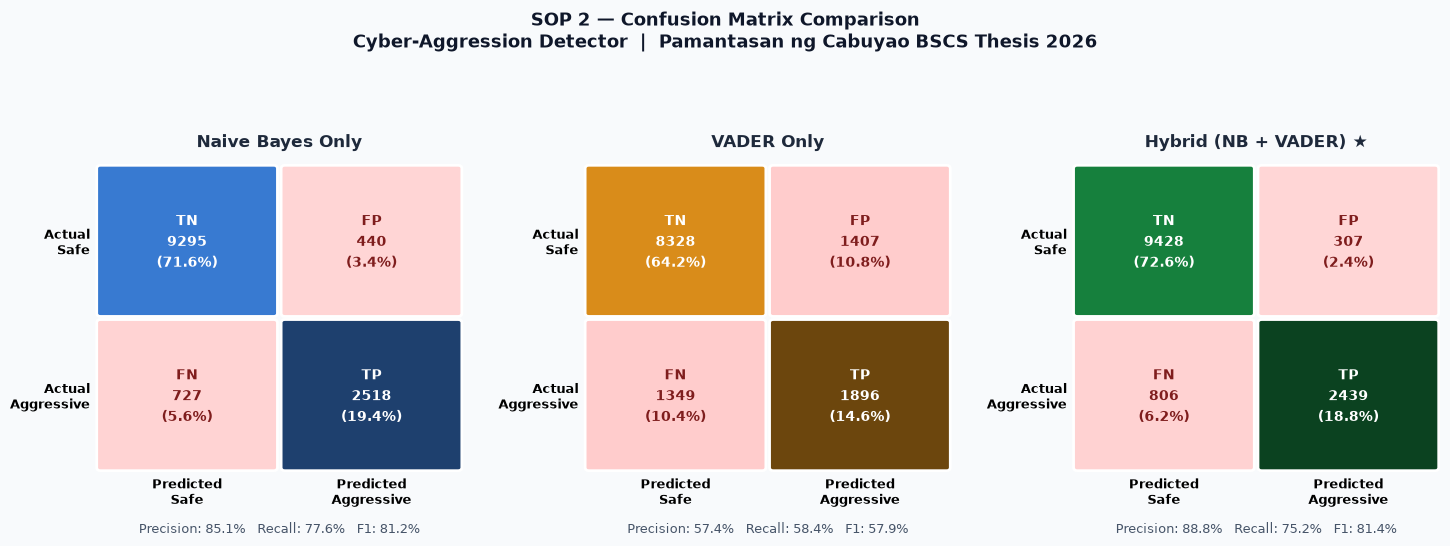

Saved: model/confusion_matrices.png


In [11]:
# CELL 11 — Confusion Matrices (Visual)
def plot_cm(ax, cm, title, color):
    tn, fp, fn, tp = cm.ravel()
    total  = tn + fp + fn + tp
    data   = [[tn, fp], [fn, tp]]
    labels = [
        [f'TN\n{tn}\n({tn/total*100:.1f}%)', f'FP\n{fp}\n({fp/total*100:.1f}%)'],
        [f'FN\n{fn}\n({fn/total*100:.1f}%)', f'TP\n{tp}\n({tp/total*100:.1f}%)']
    ]
    max_val = max(tn, fp, fn, tp)
    for i in range(2):
        for j in range(2):
            val       = data[i][j]
            intensity = val / max_val if max_val > 0 else 0
            bg = (tuple(c*(0.35+0.65*intensity) for c in color)+(1.0,)
                  if i==j else
                  (1.0, 0.85-0.3*intensity, 0.85-0.3*intensity, 1.0))
            rect = mpatches.FancyBboxPatch(
                (j+0.03, 1-i+0.03), 0.94, 0.94,
                boxstyle='round,pad=0.02',
                facecolor=bg, edgecolor='white', linewidth=2
            )
            ax.add_patch(rect)
            ax.text(j+0.5, 1-i+0.5, labels[i][j],
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if i==j else '#7f1d1d', linespacing=1.5)
    ax.set_xlim(0,2); ax.set_ylim(0,2)
    ax.set_xticks([0.5,1.5])
    ax.set_yticks([0.5,1.5])
    ax.set_xticklabels(['Predicted\nSafe','Predicted\nAggressive'], fontsize=9, fontweight='bold')
    ax.set_yticklabels(['Actual\nAggressive','Actual\nSafe'],       fontsize=9, fontweight='bold')
    ax.tick_params(length=0)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12, color='#1e293b')
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    ax.set_xlabel(f'Precision: {prec*100:.1f}%   Recall: {rec*100:.1f}%   F1: {f1*100:.1f}%',
                  fontsize=9, labelpad=10, color='#475569')
    for spine in ax.spines.values(): spine.set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor('#f8fafc')
fig.suptitle(
    'SOP 2 — Confusion Matrix Comparison\n'
    'Cyber-Aggression Detector  |  Pamantasan ng Cabuyao BSCS Thesis 2026',
    fontsize=13, fontweight='bold', color='#0f172a', y=1.02
)

cm_nb     = confusion_matrix(y_true, y_pred_nb)
cm_vader  = confusion_matrix(y_true, y_pred_vader)
cm_hybrid = confusion_matrix(y_true, y_pred_hybrid)

plot_cm(axes[0], cm_nb,     'Naive Bayes Only',      (0.22, 0.48, 0.82))
plot_cm(axes[1], cm_vader,  'VADER Only',             (0.85, 0.55, 0.10))
plot_cm(axes[2], cm_hybrid, 'Hybrid (NB + VADER) ★', (0.086, 0.50, 0.24))

for ax in axes: ax.set_facecolor('#f8fafc')
plt.tight_layout(pad=2.5)
os.makedirs('model', exist_ok=True)
plt.savefig('model/confusion_matrices.png', dpi=180, bbox_inches='tight', facecolor='#f8fafc')
plt.show()
print('Saved: model/confusion_matrices.png')

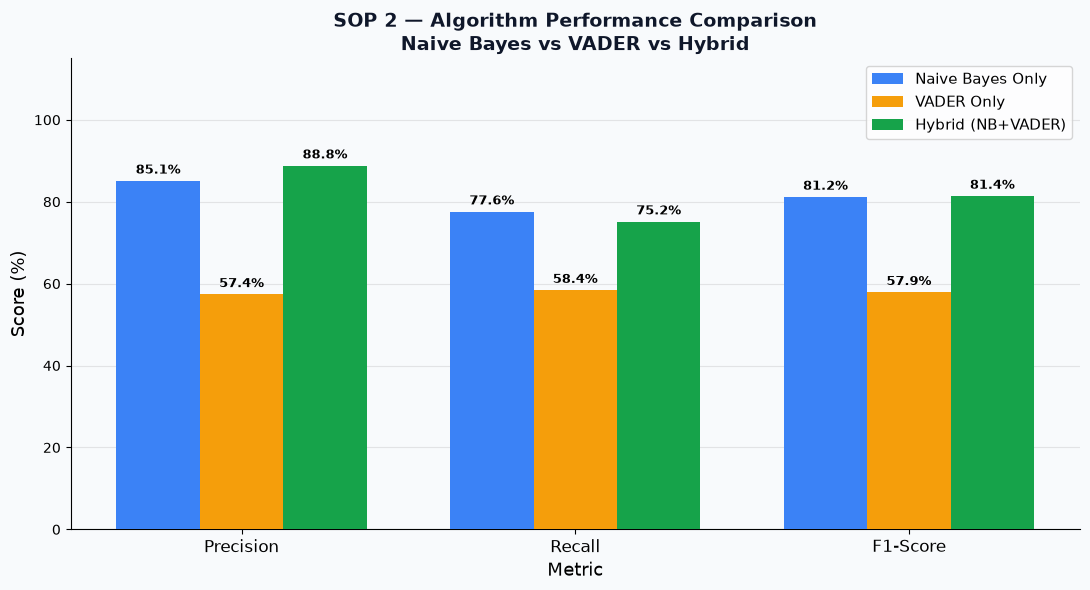

Saved: model/sop2_bar_chart.png


In [12]:
# CELL 12 — Bar Chart Comparison (Visual)
metrics  = ['Precision', 'Recall', 'F1-Score']
nb_s     = [p_nb*100,    r_nb*100,    f_nb*100]
vader_s  = [p_vader*100, r_vader*100, f_vader*100]
hybrid_s = [p_hybrid*100,r_hybrid*100,f_hybrid*100]

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

b1 = ax.bar(x-width,  nb_s,     width, label='Naive Bayes Only',  color='#3b82f6', zorder=3)
b2 = ax.bar(x,        vader_s,  width, label='VADER Only',        color='#f59e0b', zorder=3)
b3 = ax.bar(x+width,  hybrid_s, width, label='Hybrid (NB+VADER)', color='#16a34a', zorder=3)

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('SOP 2 — Algorithm Performance Comparison\nNaive Bayes vs VADER vs Hybrid',
             fontsize=14, fontweight='bold', color='#0f172a')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%',
            xy=(bar.get_x()+bar.get_width()/2, h),
            xytext=(0,3), textcoords='offset points',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model/sop2_bar_chart.png', dpi=180, bbox_inches='tight', facecolor='#f8fafc')
plt.show()
print('Saved: model/sop2_bar_chart.png')

In [13]:
# CELL 13 — Official scikit-learn Classification Report
print('=' * 65)
print('OFFICIAL scikit-learn CLASSIFICATION REPORT')
print('Evaluation Tool: Python scikit-learn')
print('=' * 65)

print('\n-- NAIVE BAYES ONLY --')
print(classification_report(y_true, y_pred_nb,
      target_names=['Non-Aggressive','Aggressive']))

print('\n-- VADER ONLY --')
print(classification_report(y_true, y_pred_vader,
      target_names=['Non-Aggressive','Aggressive']))

print('\n-- HYBRID (NB + VADER) --')
print(classification_report(y_true, y_pred_hybrid,
      target_names=['Non-Aggressive','Aggressive']))

OFFICIAL scikit-learn CLASSIFICATION REPORT
Evaluation Tool: Python scikit-learn

-- NAIVE BAYES ONLY --
                precision    recall  f1-score   support

Non-Aggressive       0.93      0.95      0.94      9735
    Aggressive       0.85      0.78      0.81      3245

      accuracy                           0.91     12980
     macro avg       0.89      0.87      0.88     12980
  weighted avg       0.91      0.91      0.91     12980


-- VADER ONLY --
                precision    recall  f1-score   support

Non-Aggressive       0.86      0.86      0.86      9735
    Aggressive       0.57      0.58      0.58      3245

      accuracy                           0.79     12980
     macro avg       0.72      0.72      0.72     12980
  weighted avg       0.79      0.79      0.79     12980


-- HYBRID (NB + VADER) --
                precision    recall  f1-score   support

Non-Aggressive       0.92      0.97      0.94      9735
    Aggressive       0.89      0.75      0.81      3245

  

In [14]:
# CELL 14 — Save Full Report
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
lines = [
    'SOP 2 EVALUATION REPORT',
    '=' * 65,
    'Title  : Real-Time Cyber-Aggression Detection and Mitigation',
    '         Using Naive Bayes and VADER in a Chrome Extension',
    'School : Pamantasan ng Cabuyao -- BSCS Thesis 2026',
    'Tool   : Python scikit-learn + Jupyter Notebook',
    f'Date   : {timestamp}',
    '',
    'DATASET',
    f'Total Samples : {len(df)}  |  Train: {len(train_df)} (80%)  |  Test: {len(test_df)} (20%)',
    'Threshold      : 0.5',
    '',
    'NAIVE BAYES ONLY',
    classification_report(y_true, y_pred_nb,     target_names=['Non-Aggressive','Aggressive']),
    'VADER ONLY',
    classification_report(y_true, y_pred_vader,  target_names=['Non-Aggressive','Aggressive']),
    'HYBRID (NB + VADER)',
    classification_report(y_true, y_pred_hybrid, target_names=['Non-Aggressive','Aggressive']),
    'COMPARISON TABLE',
    '=' * 65,
    f'{"Metric":<15} {"NB Only":>10} {"VADER Only":>12} {"Hybrid":>10}',
    '-' * 50,
    f'{"Precision":<15} {p_nb*100:>9.2f}% {p_vader*100:>11.2f}% {p_hybrid*100:>9.2f}%',
    f'{"Recall":<15} {r_nb*100:>9.2f}% {r_vader*100:>11.2f}% {r_hybrid*100:>9.2f}%',
    f'{"F1-Score":<15} {f_nb*100:>9.2f}% {f_vader*100:>11.2f}% {f_hybrid*100:>9.2f}%',
]
with open('model/sop2_report.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('All files saved:')
print('  model/sop2_report.txt         <- Text report')
print('  model/confusion_matrices.png  <- Confusion matrix visual')
print('  model/sop2_bar_chart.png      <- Bar chart comparison')
print()
print('These are your SOP 2 documentation for panel defense!')

All files saved:
  model/sop2_report.txt         <- Text report
  model/confusion_matrices.png  <- Confusion matrix visual
  model/sop2_bar_chart.png      <- Bar chart comparison

These are your SOP 2 documentation for panel defense!
